# Guided Multivariate Exploration — Penguin Size, Species, and Sex
_Morphometrics, island geography, sexual dimorphism, Simpson's paradox, and species separability in the Palmer Archipelago penguins_

***

**Programming Language:** Python in the Jupyter Notebook Environment

**Dataset:** [amulyas/penguin-size-dataset](https://www.kaggle.com/datasets/amulyas/penguin-size-dataset)

**Style counterpart:** [Guided Numeric and Text Exploration — E-Commerce](https://www.kaggle.com/code/nicapotato/guided-numeric-and-text-exploration-e-commerce)

**Code Navigation:** <br>
In the code, text after hashtags (`#`) are supportive explanations, not executed as code.

***

# Tables of Content:

**1. [Introduction](#Introduction)** <br>
**2. [Setup and Data Peek](#Setup)** <br>
**3. [Univariate Distributions](#Univariate)** <br>
**4. [Species × Island Geography](#Geography)** <br>
**5. [Sexual Dimorphism](#Dimorphism)** <br>
**6. [Simpson's Paradox: Culmen Dimensions](#Simpson)** <br>
**7. [Correlations and Pairwise Structure](#Correlations)** <br>
**8. [Species Separability (RF)](#Separability)** <br>
**9. [What It Means — Working Synthesis](#Synthesis)** <br>

# **1. Introduction:** <a id="Introduction"></a> <br>
This is the Palmer Archipelago (Antarctica) penguin morphometrics table: 344 field observations of three species — **Adelie, Chinstrap, Gentoo** — across three islands (**Biscoe, Dream, Torgersen**), with four body measurements (culmen length/depth, flipper length, body mass) plus `sex`. The guiding question is multivariate: how much of the size variation is *species*, how much is *sex within species*, and what happens to naive pooled correlations once those group structures are respected.

The culmen is the upper ridge of the bill — `culmen_length_mm` and `culmen_depth_mm` are the two bill dimensions.

# **2. Setup and Data Peek:** <a id="Setup"></a>

In [1]:
# General
import numpy as np
import pandas as pd
from pathlib import Path

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

# Scientific / modeling helpers
from IPython.display import display
from scipy import stats
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix

import kagglehub

# Set Plot Theme (same family as the guided series)
sns.set_theme(style="whitegrid")
sns.set_palette([
    "#30a2da",
    "#fc4f30",
    "#e5ae38",
    "#6d904f",
    "#8b8b8b",
])
plt.rcParams["figure.figsize"] = (11, 5)

# Warnings
import warnings
warnings.filterwarnings("ignore")

# Wide table inspection in Jupyter cell outputs
pd.set_option("display.max_columns", 999)
pd.set_option("display.width", 220)

/Users/nicapotato/Documents/repo/project/KaggleNotebooks/eda/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


**Code Explanation and Reasoning:** <br>
Three buckets: *General*, *Visualization*, and *Scientific / modeling helpers*.

`pandas` / `numpy` hold the table; `matplotlib` / `seaborn` do the graphics. `scipy.stats` backs the correlation tests and `RandomForestClassifier` closes the notebook with a species-separability drill — an exploratory measure of how much signal four morphometrics carry, not a production model. `kagglehub` resolves the CSV both on Kaggle (`/kaggle/input/...`) and locally.

The five-color palette matches the other guided notebooks so sequential plots feel like one continuous exploration.

In [2]:
# Read and Peak at Data
CSV_BASENAME = "penguins_size.csv"
KAGGLE_SLUG = "amulyas/penguin-size-dataset"
EXPECTED_COLS = [
    "species", "island", "culmen_length_mm", "culmen_depth_mm",
    "flipper_length_mm", "body_mass_g", "sex",
]
SPECIES_ORDER = ["Adelie", "Chinstrap", "Gentoo"]
ISLAND_ORDER = ["Biscoe", "Dream", "Torgersen"]
SEX_ORDER = ["MALE", "FEMALE"]
MORPH_COLS = ["culmen_length_mm", "culmen_depth_mm", "flipper_length_mm", "body_mass_g"]


def resolve_csv_path(basename: str = CSV_BASENAME) -> Path:
    kaggle_root = Path("/kaggle/input")
    if kaggle_root.exists():
        for p in kaggle_root.rglob(basename):
            return p
    local_data = Path("data") / basename
    if local_data.exists():
        return local_data
    root = Path(kagglehub.dataset_download(KAGGLE_SLUG))
    p = root / basename
    if not p.exists():
        hits = list(root.rglob(basename))
        assert hits, f"expected {basename} under {root}"
        p = hits[0]
    return p


csv_path = resolve_csv_path()
print("CSV:", csv_path)
df = pd.read_csv(csv_path)
assert list(df.columns) == EXPECTED_COLS, df.columns.tolist()
assert len(df) == 344, f"expected 344 rows, got {len(df)}"

# One record carries a '.' placeholder in sex — drop it; genuine NaN sex stays explicit (no imputation)
bad_sex = df["sex"] == "."
assert int(bad_sex.sum()) == 1
df = df.loc[~bad_sex].copy()

assert set(df["species"].unique()) == set(SPECIES_ORDER)
assert set(df["island"].unique()) == set(ISLAND_ORDER)
df["species"] = pd.Categorical(df["species"], categories=SPECIES_ORDER)
df["island"] = pd.Categorical(df["island"], categories=ISLAND_ORDER)

print("Dataframe Dimension: {} Rows, {} Columns".format(*df.shape))
print("Missing values per column:")
print(df.isnull().sum().to_string())
print("Species counts:", df["species"].value_counts().to_dict())
display(df.sample(5, random_state=7))

Dataframe Dimension: 343 Rows, 7 Columns
Missing values per column:
species               0
island                0
culmen_length_mm      2
culmen_depth_mm       2
flipper_length_mm     2
body_mass_g           2
sex                  10
Species counts: {'Adelie': 152, 'Gentoo': 123, 'Chinstrap': 68}


,species,island,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
114,Adelie,Biscoe,39.6,20.7,191.0,3900.0,FEMALE
129,Adelie,Torgersen,44.1,18.0,210.0,4000.0,MALE
188,Chinstrap,Dream,47.6,18.3,195.0,3850.0,FEMALE
261,Gentoo,Biscoe,49.6,16.0,225.0,5700.0,MALE
236,Gentoo,Biscoe,42.0,13.5,210.0,4150.0,FEMALE


**Code Explanation and Reasoning:** <br>
`resolve_csv_path` keeps the notebook runnable in both worlds: on Kaggle it walks `/kaggle/input`, locally it falls back to `kagglehub.dataset_download`, which caches the archive under `~/.cache/kagglehub`.

Two data-quality decisions happen at load time and nowhere else: the single `sex == "."` placeholder row is dropped, and the ten genuinely missing `sex` values are **kept as NaN** — those birds still carry species/island/morphometric information for every non-sex plot. Two of them are field blanks with no measurements at all; per-plot `dropna` handles that where needed. `species` and `island` become explicit categoricals so plot ordering stays fixed.

In [3]:
unique_count = [[c, df[c].nunique(dropna=False), int(df[c].isnull().sum())] for c in df.columns]
display(pd.DataFrame(unique_count, columns=["Column", "Unique", "Null"]).sort_values("Unique", ascending=False))
df[MORPH_COLS].describe().round(2)

,Column,Unique,Null
2,culmen_length_mm,165,2
5,body_mass_g,95,2
3,culmen_depth_mm,81,2
4,flipper_length_mm,56,2
0,species,3,0
1,island,3,0
6,sex,3,10


,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g
count,341.00,341.00,341.00,341.00
mean,43.92,17.16,200.87,4199.78
std,5.47,1.98,14.06,802.30
min,32.10,13.10,172.00,2700.00
25%,39.20,15.60,190.00,3550.00
50%,44.40,17.30,197.00,4050.00
75%,48.50,18.70,213.00,4750.00
max,59.60,21.50,231.00,6300.00


**Interpretation** <br>
344 observations minus one placeholder row leaves 343 penguins. The four morphometrics live on very different scales — culmen depth spans roughly 13–21 mm while body mass spans roughly 2,700–6,300 g — so later multivariate steps either use scale-free measures (correlations) or tree models that ignore scale. Missingness is tiny and structural: two all-blank field records plus a handful of unsexed birds.

# **3. Univariate Distributions:** <a id="Univariate"></a>

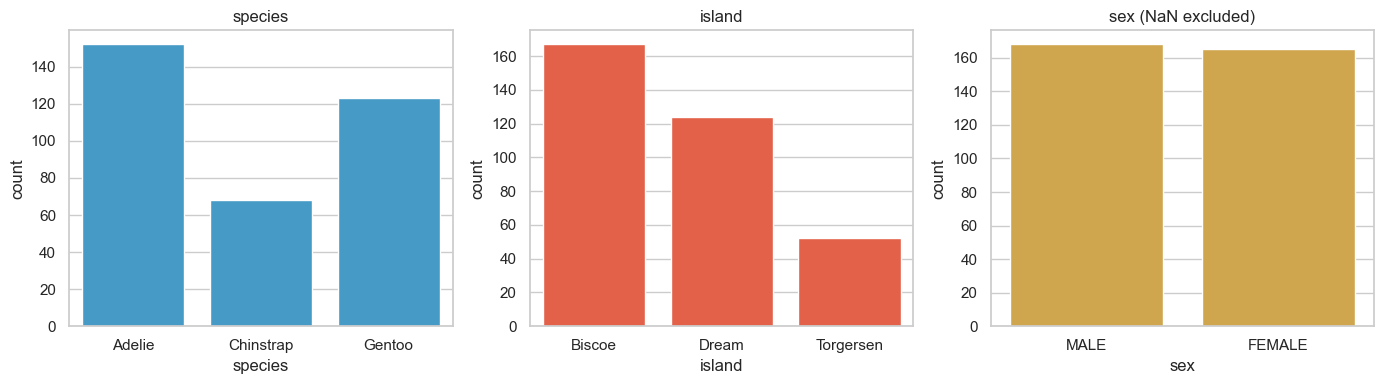

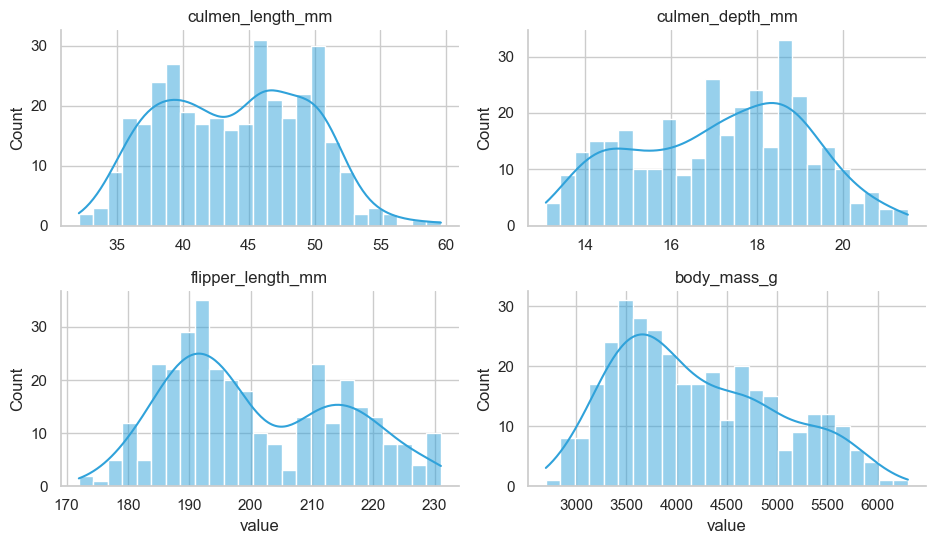

Median morphometrics by species:
           culmen_length_mm  culmen_depth_mm  flipper_length_mm  body_mass_g
species                                                                     
Adelie                 38.8             18.4              190.0       3700.0
Chinstrap              49.6             18.4              196.0       3700.0
Gentoo                 47.3             15.0              216.0       5025.0


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
sns.countplot(data=df, x="species", order=SPECIES_ORDER, ax=axes[0], color="#30a2da")
axes[0].set_title("species")
sns.countplot(data=df, x="island", order=ISLAND_ORDER, ax=axes[1], color="#fc4f30")
axes[1].set_title("island")
sns.countplot(data=df.dropna(subset=["sex"]), x="sex", order=SEX_ORDER, ax=axes[2], color="#e5ae38")
axes[2].set_title("sex (NaN excluded)")
plt.tight_layout()
plt.show()

melt = df[MORPH_COLS].melt(var_name="feature", value_name="value")
g = sns.FacetGrid(melt, col="feature", col_wrap=2, sharex=False, sharey=False, height=2.8, aspect=1.7)
g.map_dataframe(sns.histplot, x="value", bins=25, kde=True, color="#30a2da")
g.set_titles("{col_name}")
plt.show()

print("Median morphometrics by species:")
print(df.groupby("species", observed=True)[MORPH_COLS].median().round(1).to_string())

**Interpretation** <br>
Adelie is the largest group (152 birds) and Chinstrap the smallest (68); sexes are nearly balanced. All four measurement histograms look **bimodal or lumpy rather than Gaussian** — flipper length and body mass in particular show two humps. That is the species mixture leaking through: Gentoo penguins are systematically bigger, so pooled histograms overlay two size regimes. The univariate shapes are a standing warning to condition on species in everything downstream.

# **4. Species × Island Geography:** <a id="Geography"></a>

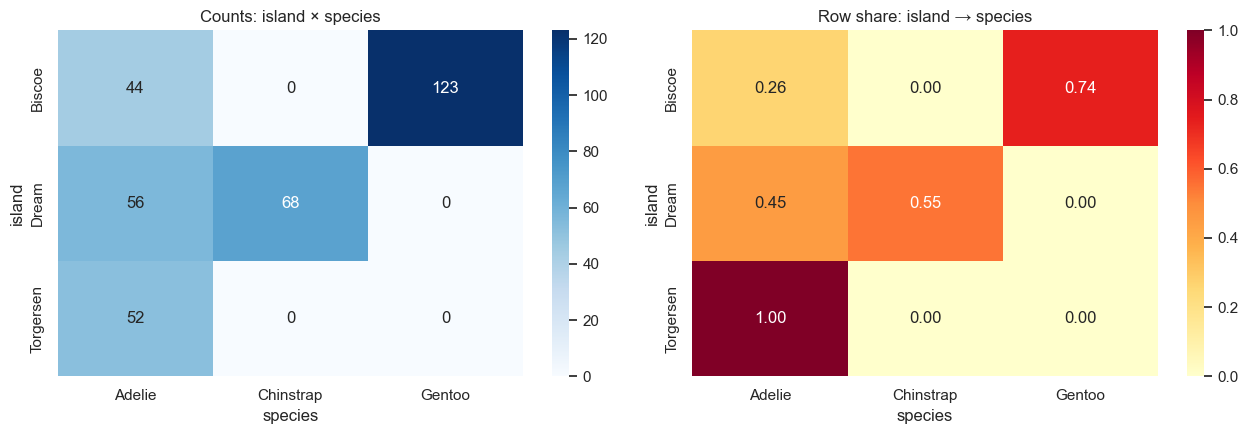

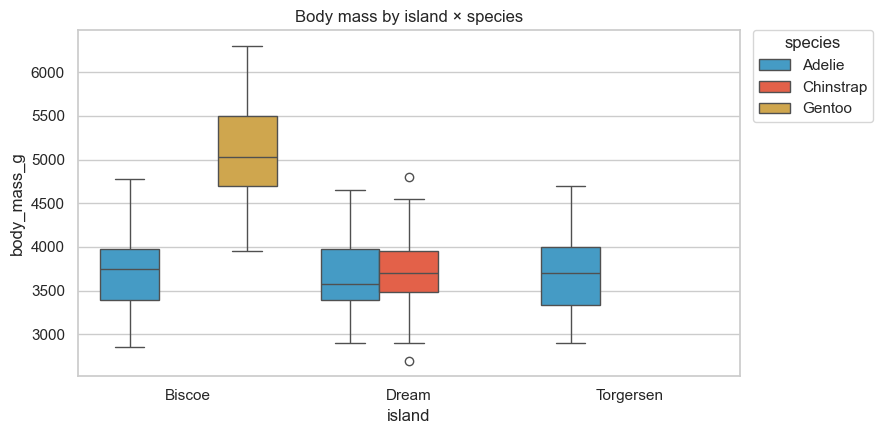

In [5]:
# Counts and row-% composition
sp_isl_n = pd.crosstab(df["island"], df["species"])
sp_isl_pct = pd.crosstab(df["island"], df["species"], normalize="index")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.heatmap(sp_isl_n, annot=True, fmt="d", cmap="Blues", ax=axes[0])
axes[0].set_title("Counts: island × species")
sns.heatmap(sp_isl_pct, annot=True, fmt=".2f", cmap="YlOrRd", ax=axes[1], vmin=0, vmax=1)
axes[1].set_title("Row share: island → species")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(9, 4.5))
sns.boxplot(
    data=df, x="island", y="body_mass_g", hue="species",
    order=ISLAND_ORDER, hue_order=SPECIES_ORDER, ax=ax,
)
ax.set_title("Body mass by island × species")
ax.legend(title="species", bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0)
plt.tight_layout()
plt.show()

**Interpretation** <br>
Geography is close to deterministic: **Gentoo breeds only on Biscoe, Chinstrap only on Dream, and Torgersen is Adelie-only**; Adelie is the one species present on all three islands. That makes `island` heavily confounded with `species` — any "penguins on Biscoe are heavier" claim is really a Gentoo effect. The box plot confirms it: within Adelie, mass barely moves across islands, while Biscoe's overall heaviness is carried entirely by its Gentoo colony.

# **5. Sexual Dimorphism:** <a id="Dimorphism"></a>

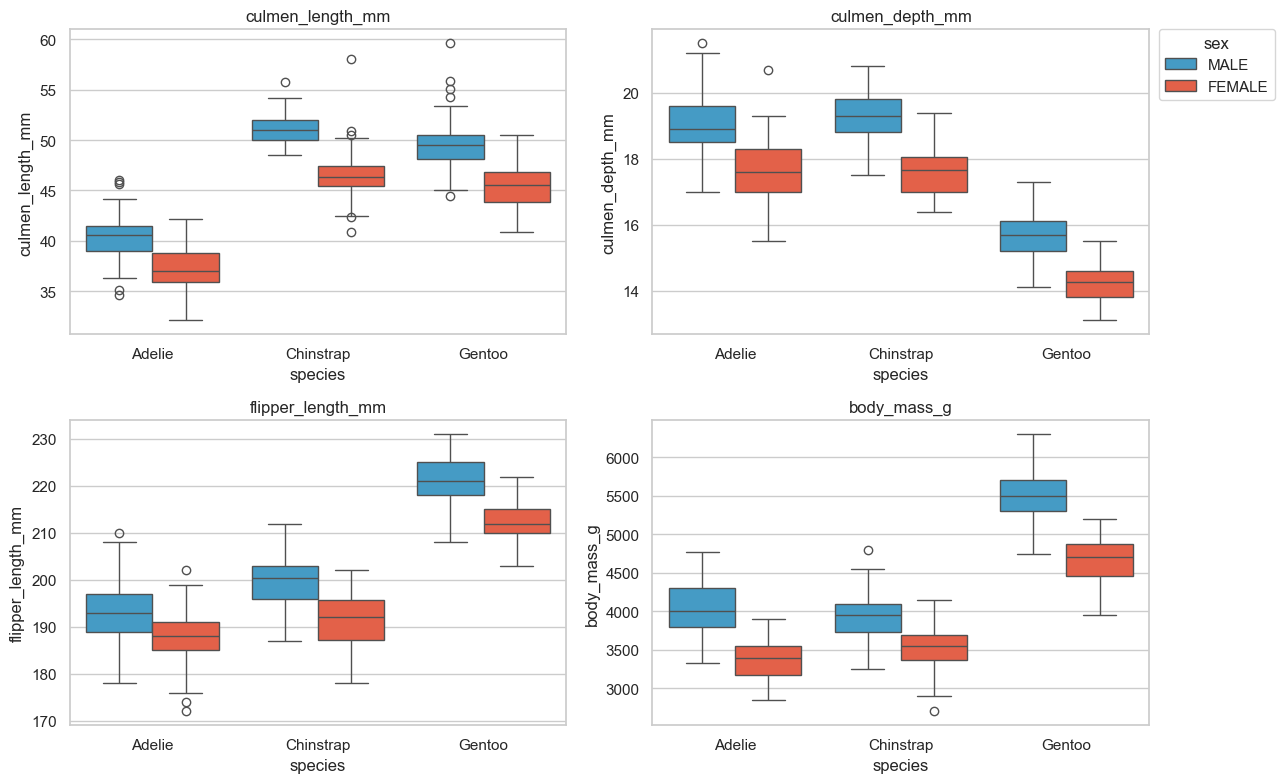

culmen_length_mm  culmen_depth_mm  flipper_length_mm  body_mass_g
species   sex                                                                      
Adelie    FEMALE              37.0             17.6              188.0       3400.0
          MALE                40.6             18.9              193.0       4000.0
Chinstrap FEMALE              46.3             17.6              192.0       3550.0
          MALE                51.0             19.3              200.5       3950.0
Gentoo    FEMALE              45.5             14.2              212.0       4700.0
          MALE                49.5             15.7              221.0       5500.0

Male / female median ratio per species:


,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g
species,,,,
Adelie,1.097,1.074,1.027,1.176
Chinstrap,1.100,1.093,1.044,1.113
Gentoo,1.088,1.102,1.042,1.170


In [6]:
sexed = df.dropna(subset=["sex"])
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
axes = axes.ravel()
for i, (ax, col) in enumerate(zip(axes, MORPH_COLS)):
    sns.boxplot(data=sexed, x="species", y=col, hue="sex", order=SPECIES_ORDER, hue_order=SEX_ORDER, ax=ax)
    ax.set_title(col)
    if i == 1:
        ax.legend(title="sex", bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0)
    else:
        ax.get_legend().remove()
plt.tight_layout()
plt.show()

med = sexed.groupby(["species", "sex"], observed=True)[MORPH_COLS].median()
display(med.round(1))

# Dimorphism ratio: male median / female median per species
dim = (med.xs("MALE", level="sex") / med.xs("FEMALE", level="sex")).round(3)
print("Male / female median ratio per species:")
display(dim)

**Interpretation** <br>
Males are consistently larger **within every species**, but the gap depends on the trait: flippers barely differ (~3–4% male advantage on medians) while body mass runs 11–18% higher and the culmen dimensions sit around 7–10%. The sex gap is still second-order next to the species gap: a female Gentoo outweighs a male Adelie. Culmen depth is the structurally interesting one: Gentoo has the *shallowest* bills despite being the heaviest bird, which is exactly why depth becomes a strong species separator later — it does not simply scale with overall size.

# **6. Simpson's Paradox: Culmen Dimensions:** <a id="Simpson"></a>

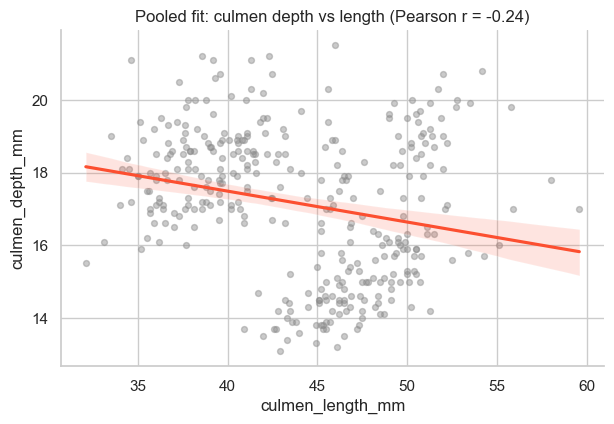

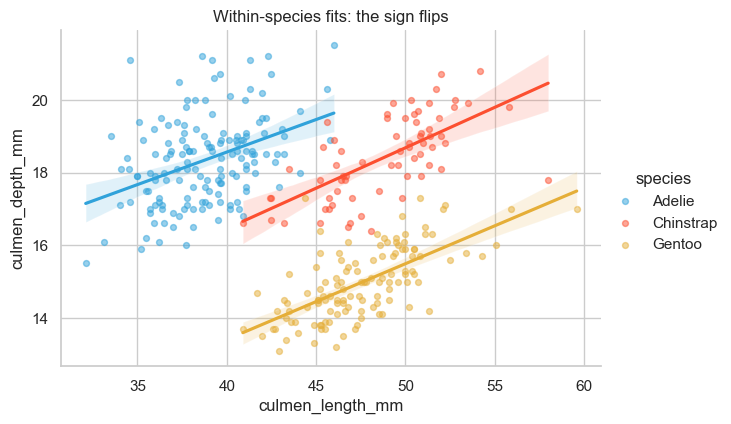

,species,n,pearson_r,p_value
0,Adelie,151,0.391,6.674141e-07
1,Chinstrap,68,0.654,1.525539e-09
2,Gentoo,122,0.653,3.471673e-16


Pooled r = -0.235 vs within-species r all positive → Simpson's paradox


In [7]:
sub = df.dropna(subset=["culmen_length_mm", "culmen_depth_mm"]).copy()
pooled_r = float(sub["culmen_length_mm"].corr(sub["culmen_depth_mm"]))

g = sns.lmplot(
    data=sub, x="culmen_length_mm", y="culmen_depth_mm",
    height=4.2, aspect=1.5, scatter_kws={"alpha": 0.45, "s": 18, "color": "#8b8b8b"},
    line_kws={"color": "#fc4f30"},
)
g.ax.set_title(f"Pooled fit: culmen depth vs length (Pearson r = {pooled_r:.2f})")
plt.show()

g = sns.lmplot(
    data=sub, x="culmen_length_mm", y="culmen_depth_mm", hue="species", hue_order=SPECIES_ORDER,
    height=4.2, aspect=1.5, scatter_kws={"alpha": 0.5, "s": 18},
)
g.ax.set_title("Within-species fits: the sign flips")
plt.show()

rows = []
for s, grp in sub.groupby("species", observed=True):
    r, p = stats.pearsonr(grp["culmen_length_mm"], grp["culmen_depth_mm"])
    rows.append({"species": s, "n": len(grp), "pearson_r": round(float(r), 3), "p_value": float(p)})
within = pd.DataFrame(rows)
display(within)
print(f"Pooled r = {pooled_r:.3f} vs within-species r all positive → Simpson's paradox")

**Interpretation** <br>
This is the textbook **Simpson's paradox** pair. Pooled across all birds, culmen length and depth correlate *negatively* — long bills look shallow — because Gentoo combines the longest and the shallowest bills, dragging the global fit down. Condition on species and every within-group correlation is solidly *positive* (bigger birds have bigger bills in both dimensions, p ≪ 0.05 in each group). The pooled slope answers a question about species composition, not about penguin anatomy.

# **7. Correlations and Pairwise Structure:** <a id="Correlations"></a>

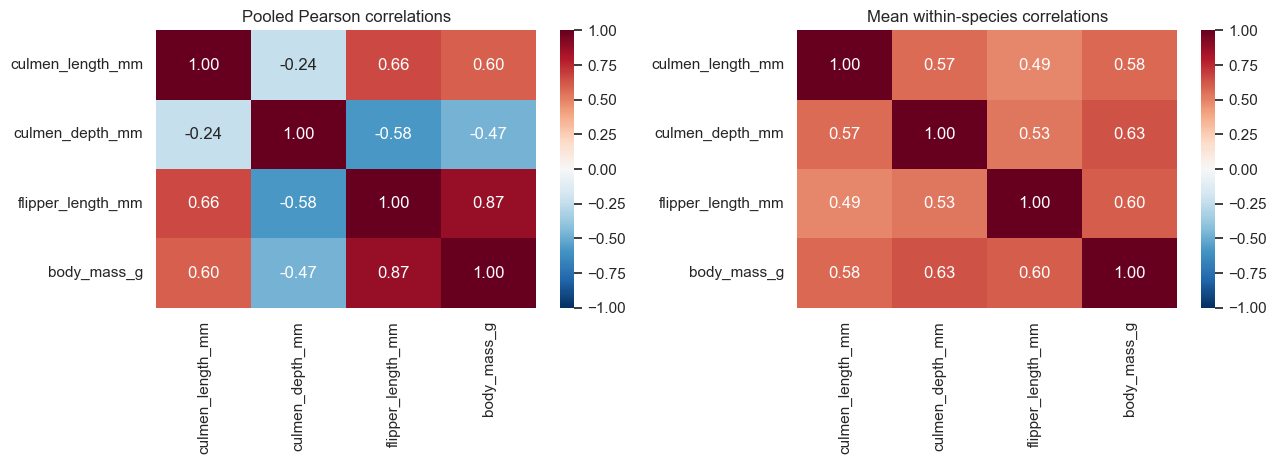

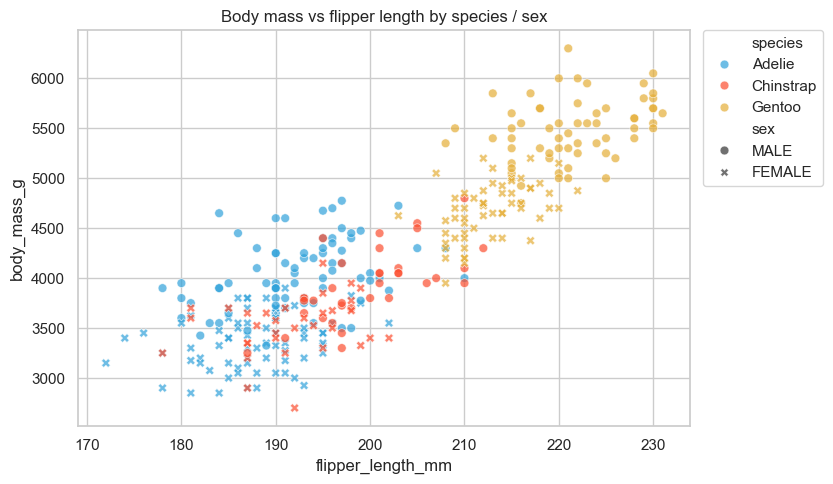

Pooled r(flipper, mass): 0.871


In [8]:
comp = df.dropna(subset=MORPH_COLS)
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
sns.heatmap(comp[MORPH_COLS].corr(), annot=True, fmt=".2f", cmap="RdBu_r", center=0, vmin=-1, vmax=1, ax=axes[0])
axes[0].set_title("Pooled Pearson correlations")

# Mean of within-species correlation matrices — group structure removed
within_mats = [grp[MORPH_COLS].corr() for _, grp in comp.groupby("species", observed=True)]
within_mean = sum(within_mats) / len(within_mats)
sns.heatmap(within_mean, annot=True, fmt=".2f", cmap="RdBu_r", center=0, vmin=-1, vmax=1, ax=axes[1])
axes[1].set_title("Mean within-species correlations")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(8.5, 5))
sns.scatterplot(
    data=comp.dropna(subset=["sex"]), x="flipper_length_mm", y="body_mass_g",
    hue="species", hue_order=SPECIES_ORDER, style="sex", alpha=0.7, s=40, ax=ax,
)
ax.set_title("Body mass vs flipper length by species / sex")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0)
plt.tight_layout()
plt.show()
print("Pooled r(flipper, mass):", round(float(comp["flipper_length_mm"].corr(comp["body_mass_g"])), 3))

**Interpretation** <br>
Flipper length and body mass are the tightest pair (pooled r ≈ 0.87) and stay strongly related within species — genuine allometry, not composition. The culmen-depth row is where the pooled and within-species matrices disagree most, which is the Simpson signature from section 6 showing up matrix-wide. The scatter shows three clean species clouds with sex shifting each cloud along its own axis: species sets the neighborhood, sex fine-tunes the position inside it.

# **8. Species Separability (RF):** <a id="Separability"></a>

Hold-out accuracy: 0.961  (test n = 103)


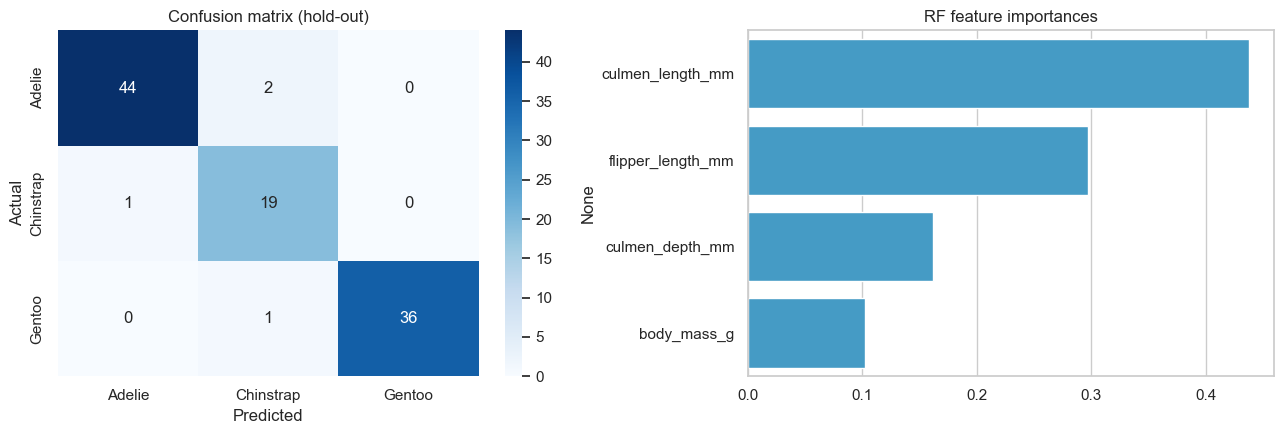

culmen_length_mm     0.438
flipper_length_mm    0.298
culmen_depth_mm      0.162
body_mass_g          0.102


In [9]:
# RF species classifier from the four morphometrics — a separability check, not a production model
model_df = df.dropna(subset=MORPH_COLS).copy()
X = model_df[MORPH_COLS]
y = model_df["species"].astype(str)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=7, stratify=y)

rf = RandomForestClassifier(n_estimators=300, random_state=7, n_jobs=-1)
rf.fit(X_train, y_train)
pred = rf.predict(X_test)
acc = accuracy_score(y_test, pred)
print(f"Hold-out accuracy: {acc:.3f}  (test n = {len(y_test)})")

cm = confusion_matrix(y_test, pred, labels=SPECIES_ORDER)
imp = pd.Series(rf.feature_importances_, index=MORPH_COLS).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=SPECIES_ORDER, yticklabels=SPECIES_ORDER, ax=axes[0])
axes[0].set_title("Confusion matrix (hold-out)")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")
sns.barplot(x=imp.values, y=imp.index, ax=axes[1], color="#30a2da")
axes[1].set_title("RF feature importances")
plt.tight_layout()
plt.show()
print(imp.round(3).to_string())

**Interpretation** <br>
Four body measurements are nearly sufficient to name the species — hold-out accuracy lands around 96%, with the residual confusion between Adelie and Chinstrap, the two smaller species that share Dream island. Culmen length is the single strongest separator (importance ≈ 0.44): it splits short-billed Adelie from the other two. Flipper length comes second (≈ 0.30) as the Gentoo size marker, with culmen depth (≈ 0.16) reinforcing the shallow-billed Gentoo signal; body mass adds least, being largely a noisier echo of flipper length.

# **9. What It Means — Working Synthesis:** <a id="Synthesis"></a>

**What the table is:** <br>
343 usable Palmer Archipelago penguins with species, island, sex, and four morphometrics.

**Working takeaways:** <br>
- Geography is nearly deterministic: Gentoo→Biscoe, Chinstrap→Dream, Torgersen is Adelie-only — `island` is a species proxy, not an independent factor.
- Pooled univariate distributions are bimodal because they mix size regimes; conditioning on species is mandatory.
- Sexual dimorphism is real (from ~3% on flippers to ~11–18% on body mass) but second-order next to the species gap.
- Culmen length × depth is a live Simpson's paradox: pooled r ≈ −0.24, within-species r all positive.
- Flipper ↔ body mass is the robust allometric pair (r ≈ 0.87 pooled, strong within species too).
- An RF on four measurements recovers species at ~96% hold-out accuracy; culmen length carries the most signal, followed by flipper length.

**Open follow-ups:** <br>
- Two-way ANOVA (species × sex) to formally partition variance per morphometric.
- LDA projection to visualize the two discriminant axes behind the RF result.
- Predict sex for the unsexed birds within species and sanity-check against the dimorphism ratios.
- Island effects *within* Adelie (the only species on all three islands) as a clean geography test.